#  Algorithmic Optimization & Validation
In this notebook, we move from data preparation to strategy. We will use statistical methods to find the optimal number of customer segments.

**Objectives:**
* Apply the **Elbow Method** to find the balance between model complexity and error.
* Use **Silhouette Analysis** for precise cluster validation.
* Finalize the K-Means model for our real-world dataset.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df_pca = pd.read_csv('processed_pca_data.csv')

## 1. The Elbow Method (WCSS)
To find the optimal $k$, we calculate the **Within-Cluster Sum of Squares (WCSS)**. This metric represents the sum of squared distances between each data point and the centroid of its assigned cluster.

$$WCSS = \sum_{i \in Cluster_j} dist(x_i, C_j)^2$$

We look for the "elbow point" on the graph—the point where the rate of decrease in WCSS slows down significantly. This point represents a balance between model precision and simplicity (avoiding overfitting).

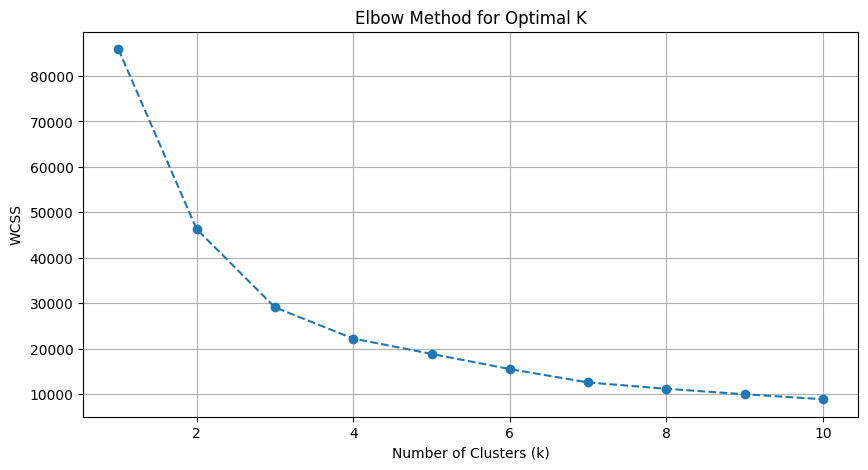

In [9]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

## 2. Silhouette Analysis
While WCSS measures compactness, the **Silhouette Score** measures how well-separated the clusters are. The score ranges from -1 to 1:
* **Near 1:** Points are far from neighboring clusters (excellent separation).
* **Near 0:** Clusters are overlapping.
* **Negative:** Points may be assigned to the wrong cluster.

We use this score to validate the choice made during the Elbow Method, ensuring our segments are distinct.

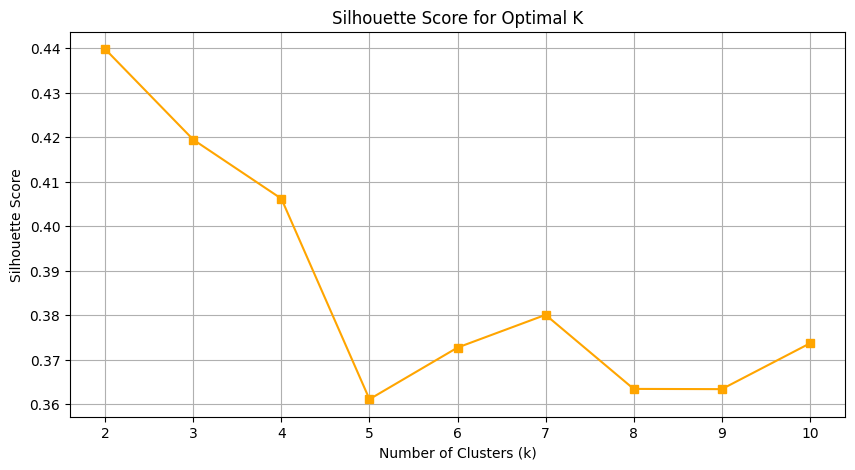

In [10]:
silhouette_avg = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    cluster_labels = kmeans.fit_predict(df_pca)
    silhouette_avg.append(silhouette_score(df_pca, cluster_labels))

plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), silhouette_avg, marker='s', color='orange')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

## 3. Final Model Implementation
Based on the combined analysis of the Elbow Method and Silhouette Scores, we select **$k = 4$**. This number of clusters provides a granular enough segmentation for business targeting without becoming overly complex to interpret.

We utilize `KMeans` with the `k-means++` initialization to ensure stable convergence and avoid the "random initialization trap" discussed in Notebook 1.

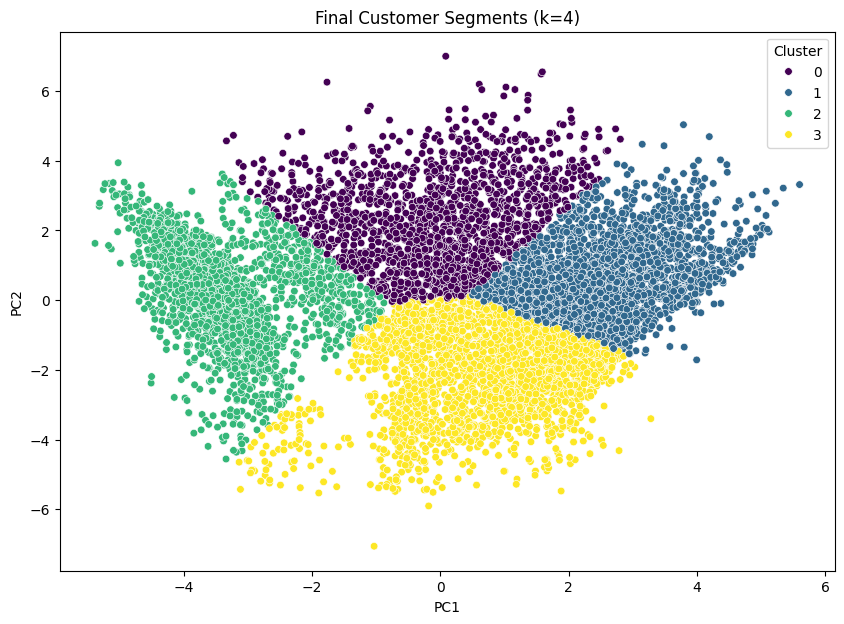

In [11]:
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df_pca['Cluster'] = kmeans_final.fit_predict(df_pca)

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=30)
plt.title(f'Final Customer Segments (k={optimal_k})')
plt.show()

## 4. Visualization & Initial Findings
The final plot displays our 8,950 customers divided into 4 distinct segments within the PCA space. Although real-world data is inherently noisier than our synthetic simulations, the clusters show clear boundaries.

**Next Steps:**
In **Notebook 4 (Cluster Profiling)**, we will "decode" these segments by mapping them back to their original financial metrics (Balance, Purchases, Cash Advance, etc.) to define actionable business personas.